In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('/olist_orders_dataset.csv')
products = pd.read_csv('/olist_products_dataset.csv')
reviews = pd.read_csv('/olist_order_reviews_dataset.csv')
items = pd.read_csv('/olist_order_items_dataset.csv')
customers = pd.read_csv('/olist_customers_dataset.csv')

products['product_category_name'] = products['product_category_name'].fillna('unknown')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No comment')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

orders.drop_duplicates(inplace=True)
items.drop_duplicates(inplace=True)

df = items.merge(orders, on='order_id', how='inner')
df = df.merge(customers, on='customer_id', how='inner')
df = df.merge(products, on='product_id', how='inner')
df = df.merge(reviews, on='order_id', how='inner')

print(df.shape)

(112372, 33)


In [4]:
rev_by_cat = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False)
print(rev_by_cat.head(5))

rev_by_month = df.groupby('order_month')['price'].sum().sort_values(ascending=False)
print(rev_by_month.head(1))

rev_by_region = df.groupby('customer_state')['price'].sum().sort_values(ascending=False)
print(rev_by_region.head(5))

aov_trend = df.groupby('order_month').apply(lambda x: x['price'].sum() / x['order_id'].nunique())
print(aov_trend.head(5))

review_dist = df['review_score'].value_counts(normalize=True) * 100
print(review_dist)

product_category_name
beleza_saude              1252404.85
relogios_presentes        1197565.48
cama_mesa_banho           1040140.31
esporte_lazer              986848.92
informatica_acessorios     914579.39
Name: price, dtype: float64
order_month
2017-11    1008127.73
Freq: M, Name: price, dtype: float64
customer_state
SP    5195744.48
RJ    1803168.25
MG    1577629.10
RS     751552.02
PR     683400.25
Name: price, dtype: float64
order_month
2016-09     89.120000
2016-10    161.181188
2016-12     10.900000
2017-01    153.908395
2017-02    143.639222
Freq: M, dtype: float64
review_score
5    56.530986
4    18.968248
1    12.667746
3     8.385541
2     3.447478
Name: proportion, dtype: float64


/tmp/ipykernel_1928/3236856355.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aov_trend = df.groupby('order_month').apply(lambda x: x['price'].sum() / x['order_id'].nunique())


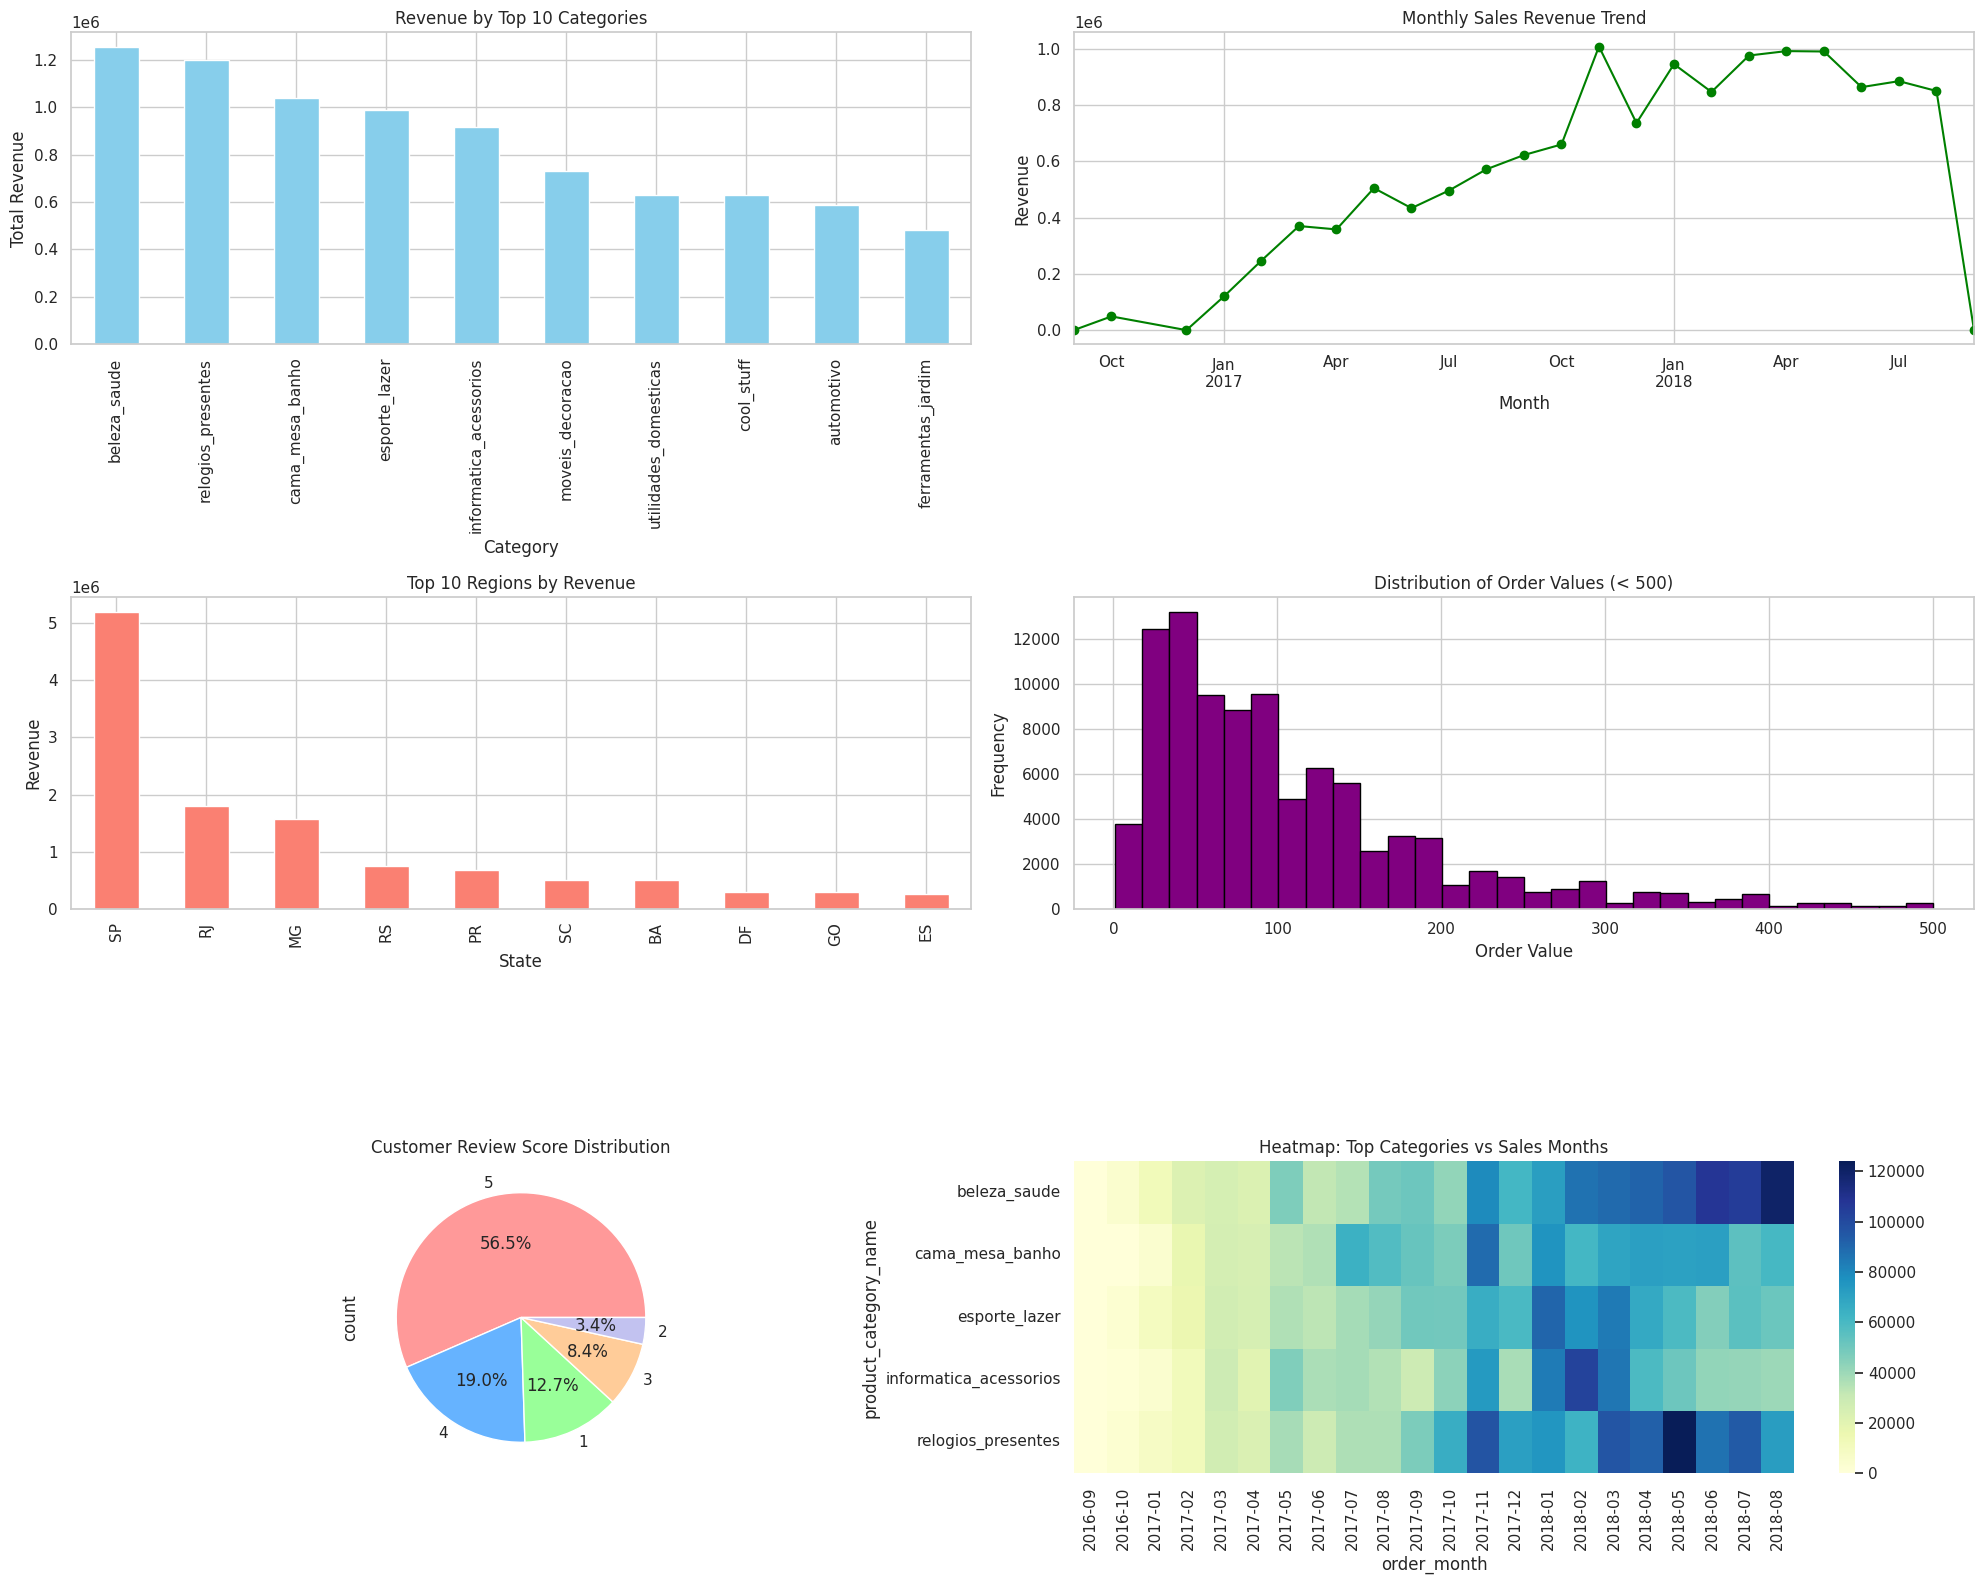

In [5]:
plt.figure(figsize=(20, 16))
sns.set_theme(style="whitegrid")

plt.subplot(3, 2, 1)
rev_by_cat.head(10).plot(kind='bar', color='skyblue')
plt.title('Revenue by Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

plt.subplot(3, 2, 2)
df.groupby('order_month')['price'].sum().plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.subplot(3, 2, 3)
rev_by_region.head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Regions by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.subplot(3, 2, 4)
order_values = df.groupby('order_id')['price'].sum()
plt.hist(order_values[order_values < 500], bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Order Values (< 500)')
plt.xlabel('Order Value')
plt.ylabel('Frequency')

plt.subplot(3, 2, 5)
df['review_score'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.title('Customer Review Score Distribution')

plt.subplot(3, 2, 6)
top_5_cats = rev_by_cat.head(5).index
pivot_df = df[df['product_category_name'].isin(top_5_cats)].pivot_table(index='product_category_name', columns='order_month', values='price', aggfunc='sum').fillna(0)
sns.heatmap(pivot_df, cmap='YlGnBu')
plt.title('Heatmap: Top Categories vs Sales Months')

plt.tight_layout()
plt.show()

In [6]:
df.to_csv('olist_master_clean.csv', index=False)